# Feature Compatibility → Survival

Group interactions by whether each feature matches (light, water, soil, care, climate, zone) and compare label (survival) rates.

**Expected:** Water mismatches should drop survival more than zone mismatches (oracle weights: water 27%, zone 10%).

## 1. Setup & Imports

In [56]:
import json
import sys
from collections import defaultdict
from pathlib import Path

# Project root: run notebook from project root (cd HowToKeepYourPlantsAlive && jupyter notebook)
ROOT = Path.cwd()
if not (ROOT / "resources").exists():
    for c in [ROOT.parent, ROOT.parent.parent, ROOT.parent.parent.parent]:
        if (c / "resources").exists():
            ROOT = c
            break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

INTERACTIONS_PATH = ROOT / "resources" / "data" / "synthetic_interactions.json"
USERS_PATH = ROOT / "resources" / "data" / "synthetic_users.json"
PLANTS_PATH = ROOT / "resources" / "data_creating" / "permapeople_plants_mapped_normalized.json"
PLANTS_ALT = ROOT / "resources" / "data_creating" / "permapeople_plants_mapped_uniform.json"
OUTPUT_DIR = ROOT / "resources" / "verify" / "feature compactability"

## 2. Helper Functions

In [57]:
LIGHT_ORDER = ["full shade", "partial sun/shade", "full sun"]
SOIL_ORDER = ["light", "medium", "heavy"]
CARE_ORDER = ["easy", "medium", "hard"]
CLIMATE_ORDER = ["alpine", "arid", "mediterranean", "temperate", "tropical"]

def _norm(v):
    if v is None: return None
    return str(v).strip().lower() or None

def _plant_ec(plant: dict, key: str, alt: str | None = None) -> dict:
    ec = plant.get("environment_care") or {}
    return ec.get(key) or ec.get(alt or key) or {}

def _plant_val(plant: dict, key: str) -> str | None:
    ec = plant.get("environment_care") or {}
    return ec.get(key)

def _extract_plant_usda_zone(plant: dict) -> tuple[int, int]:
    ec = plant.get("environment_care") or {}
    usda = ec.get("USDA Hardiness zone")
    min_z, max_z = ec.get("usda_zone_min"), ec.get("usda_zone_max")
    if min_z is not None and max_z is not None:
        return max(1, min(13, int(min_z))), max(1, min(13, int(max_z)))
    if isinstance(usda, dict):
        min_z = usda.get("min", 3)
        max_z = usda.get("max", 9)
        return max(1, min(13, int(min_z))), max(1, min(13, int(max_z)))
    return (3, 9)

def _ordinal_distance(user_val, plant_vals: list, order: list) -> float:
    if not user_val or not plant_vals: return 0.0
    uv = _norm(user_val)
    if not uv: return 0.0
    rank_map = {_norm(v): i for i, v in enumerate(order)}
    user_rank = rank_map.get(uv)
    if user_rank is None: return 0.0
    plant_ranks = [rank_map.get(_norm(p)) for p in plant_vals if p]
    plant_ranks = [r for r in plant_ranks if r is not None]
    if not plant_ranks: return 0.0
    if user_rank in plant_ranks: return 0.0
    return min(abs(user_rank - r) for r in plant_ranks)

def _zone_overlap(user_min, user_max, plant_min, plant_max) -> float:
    overlap = max(0, min(user_max, plant_max) - max(user_min, plant_min) + 1)
    span = user_max - user_min + 1
    return overlap / span if span > 0 else 0.0

## 3. Feature Match Logic

In [58]:
def feature_match(interaction: dict, user: dict, plant: dict) -> dict[str, bool]:
    """Return dict of feature_name -> True if match, False if mismatch."""
    ec = plant.get("environment_care") or {}
    result = {}

    # Light
    lr = _plant_ec(plant, "lighting", "light_req")
    ideal, toler = lr.get("ideal_light"), lr.get("tolerated_light") or lr.get("ideal_light")
    plant_lights = [v for v in (ideal, toler) if v]
    result["light"] = _ordinal_distance(user.get("light"), plant_lights, LIGHT_ORDER) == 0.0

    # Water
    from resources.ETL.feature_engineer import water_freq_to_days
    wr = _plant_ec(plant, "water", "water_req")
    ideal_d = wr.get("ideal_water_days") or water_freq_to_days(wr.get("ideal_water"))
    toler_d = wr.get("tolerated_water_days") or water_freq_to_days(wr.get("tolerated_water"))
    p_min = min(ideal_d, toler_d) if ideal_d and toler_d else 2
    p_max = max(ideal_d, toler_d) if ideal_d and toler_d else 2
    uf = user.get("water_freq")
    result["water"] = (uf is not None and p_min <= float(uf) <= p_max) if uf is not None else True

    # Soil
    sr = _plant_ec(plant, "soil", "soil_req")
    ideal_s, toler_s = sr.get("ideal_soil"), sr.get("tolerated_soil") or sr.get("ideal_soil")
    plant_soils = [v for v in (ideal_s, toler_s) if v]
    result["soil"] = _ordinal_distance(user.get("soil"), plant_soils, SOIL_ORDER) == 0.0

    # Care: user >= plant
    pc = _norm(plant.get("care_level") or ec.get("care_level")) or "medium"
    uc = _norm(user.get("care_level"))
    rank = {_norm(v): i for i, v in enumerate(CARE_ORDER)}
    ur, pr = rank.get(uc) if uc else None, rank.get(pc)
    result["care"] = (ur is not None and pr is not None and ur >= pr) if (ur is not None and pr is not None) else True

    # Climate
    plc = _norm(_plant_val(plant, "origin_climate"))
    result["climate"] = _ordinal_distance(user.get("climate"), [plc] if plc else [], CLIMATE_ORDER) == 0.0

    # Zone
    u_min, u_max = user.get("usda_zone_min"), user.get("usda_zone_max")
    if u_min is not None and u_max is not None:
        p_min, p_max = _extract_plant_usda_zone(plant)
        result["zone"] = _zone_overlap(int(u_min), int(u_max), p_min, p_max) > 0
    else:
        result["zone"] = True

    return result

## 4. Load Data

In [59]:
def load_data():
    with open(INTERACTIONS_PATH) as f:
        interactions = json.load(f)
    with open(USERS_PATH) as f:
        users = json.load(f)
    path = PLANTS_PATH if PLANTS_PATH.exists() else PLANTS_ALT
    with open(path) as f:
        plants = json.load(f).get("plants", [])
    user_by_id = {u["user_id"]: u for u in users}
    plant_by_id = {p.get("id"): p for p in plants if p.get("id") is not None}
    return interactions, user_by_id, plant_by_id

interactions, user_by_id, plant_by_id = load_data()
print(f"{len(interactions)} interactions, {len(user_by_id)} users, {len(plant_by_id)} plants")

11206 interactions, 810 users, 1000 plants


## 5. Compute Survival by Feature

In [60]:
def compute_survival_by_feature(interactions, user_by_id, plant_by_id):
    by_feature = defaultdict(lambda: {"match": [], "mismatch": []})
    for i in interactions:
        u = user_by_id.get(i["user_id"], {})
        p = plant_by_id.get(i["plant_id"]) or {}
        if not p: continue
        label = i.get("label", 0)
        matches = feature_match(i, u, p)
        for feat, is_match in matches.items():
            bucket = "match" if is_match else "mismatch"
            by_feature[feat][bucket].append(label)
    result = {}
    for feat, d in by_feature.items():
        m_labels, mm_labels = d["match"], d["mismatch"]
        mr = sum(m_labels) / len(m_labels) if m_labels else 0
        mmr = sum(mm_labels) / len(mm_labels) if mm_labels else 0
        result[feat] = {
            "match": {"n": len(m_labels), "survival_rate": mr},
            "mismatch": {"n": len(mm_labels), "survival_rate": mmr},
            "survival_drop": mr - mmr,
        }
    return result

stats = compute_survival_by_feature(interactions, user_by_id, plant_by_id)

## 6. Print Results

In [61]:
features = ["light", "water", "soil", "care", "climate", "zone"]
for feat in features:
    s = stats[feat]
    mr, mmr = s["match"]["survival_rate"], s["mismatch"]["survival_rate"]
    print(f"{feat}: match={mr:.3f} (n={s['match']['n']})  mismatch={mmr:.3f} (n={s['mismatch']['n']})  drop={s['survival_drop']:.3f}")

light: match=0.728 (n=5616)  mismatch=0.586 (n=5590)  drop=0.142
water: match=0.754 (n=2613)  mismatch=0.628 (n=8593)  drop=0.127
soil: match=0.688 (n=7491)  mismatch=0.594 (n=3715)  drop=0.094
care: match=0.736 (n=6283)  mismatch=0.556 (n=4923)  drop=0.180
climate: match=0.763 (n=2234)  mismatch=0.631 (n=8972)  drop=0.132
zone: match=0.715 (n=6122)  mismatch=0.588 (n=5084)  drop=0.127


## 7. Plot

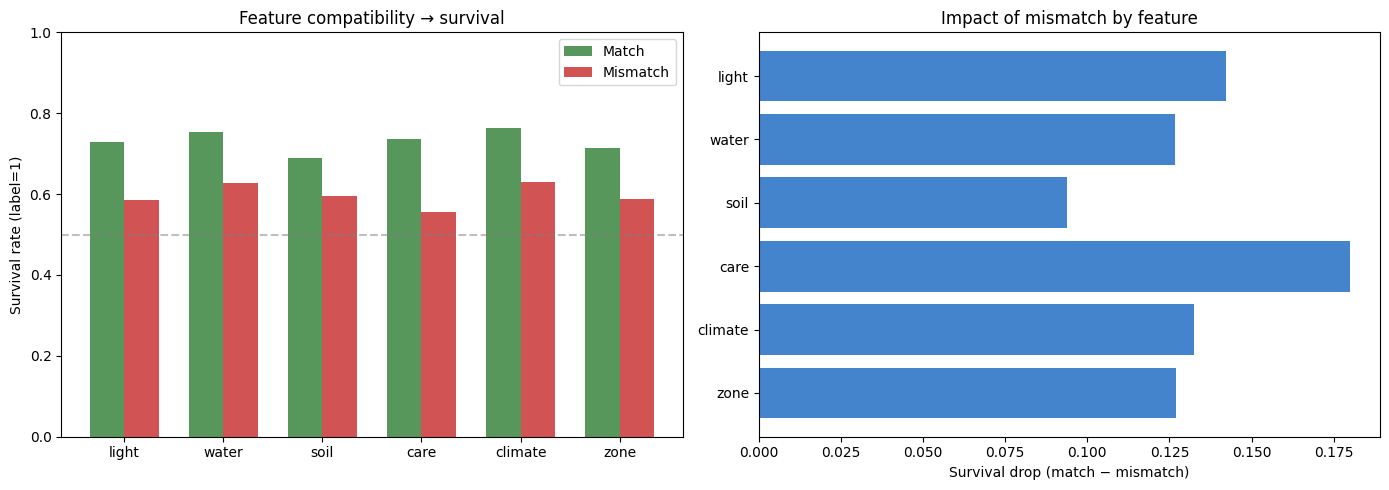

In [62]:
import matplotlib.pyplot as plt

match_rates = [stats[f]["match"]["survival_rate"] for f in features]
mismatch_rates = [stats[f]["mismatch"]["survival_rate"] for f in features]
drops = [stats[f]["survival_drop"] for f in features]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")

# Left: grouped bar chart
x = range(len(features))
w = 0.35
axes[0].bar([i - w/2 for i in x], match_rates, w, label="Match", color="#2e7d32", alpha=0.8)
axes[0].bar([i + w/2 for i in x], mismatch_rates, w, label="Mismatch", color="#c62828", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(features)
axes[0].set_ylabel("Survival rate (label=1)")
axes[0].set_title("Feature compatibility → survival")
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)

# Right: survival drop per feature
colors = ["#1565c0" if d > 0 else "#c62828" for d in drops]
axes[1].barh(features, drops, color=colors, alpha=0.8)
axes[1].axvline(x=0, color="black", linewidth=0.5)
axes[1].set_xlabel("Survival drop (match − mismatch)")
axes[1].set_title("Impact of mismatch by feature")
axes[1].invert_yaxis()

plt.tight_layout()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "feature_compatibility_survival.png", dpi=120, bbox_inches="tight", facecolor="white")
plt.show()

## 8. Model-based Pattern Analysis

Run inference with the two-tower model on each interaction and group model scores by feature match/mismatch. If the model has learned feature compatibility, **mean model score should be higher for match than mismatch** per feature. Requires `two_tower.pt` (run training or `dvc pull`).

In [63]:
import torch
from resources.ETL.feature_engineer import apply_user_embeddings, apply_categorical_embeddings

# Apply 21-dim categorical_embedding to users and plants (same schema as training)
users_list = list(user_by_id.values())
plants_list = list(plant_by_id.values())
apply_user_embeddings(users_list)
apply_categorical_embeddings(plants_list)
# Rebuild id->dict (in-place mutation)
user_by_id = {u["user_id"]: u for u in users_list}
plant_by_id = {p.get("id"): p for p in plants_list}

# Model paths to try (training_script vs retrain/DVC)
MODEL_PATHS = [
    ROOT / "resources" / "two_tower_training" / "two_tower.pt",
    ROOT / "resources" / "two_tower_training" / "output" / "two_tower.pt",
]
model = None
for p in MODEL_PATHS:
    if p.exists():
        ckpt = torch.load(p, map_location="cpu", weights_only=True)
        state = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
        # Detect 21-dim two_tower_model (mlp) vs old 7-cat feature_loader (embed_light)
        if any("user_tower.mlp" in k for k in state.keys()):
            from resources.two_tower_training.two_tower_model import TwoTowerModel
            model = TwoTowerModel()
            model.load_state_dict(state, strict=True)
            model.eval()
            print(f"Loaded 21-dim model from {p}")
            break
        elif any("user_tower.embed_light" in k for k in state.keys()):
            print("Skipping: checkpoint is old 7-cat architecture (incompatible with synthetic user format)")
if model is None:
    print("Model not found. Skip model analysis. Run: python -m resources.two_tower_training.training_script or dvc pull")

Loaded 21-dim model from /Users/yemarnaung/Documents/Projects/HowToKeepYourPlantsAlive/resources/two_tower_training/output/two_tower.pt


In [64]:
def compute_model_scores_by_feature(interactions, user_by_id, plant_by_id, model):
    """Bucket interactions by feature match/mismatch; compute mean model score per bucket."""
    batch_u, batch_p, batch_buckets = [], [], []  # buckets: list of {feat: "match"|"mismatch"} per row
    for r in interactions:
        u = user_by_id.get(r["user_id"], {})
        p = plant_by_id.get(r["plant_id"]) or {}
        if not p or "categorical_embedding" not in p:
            continue
        u_emb = u.get("categorical_embedding")
        if not u_emb or len(u_emb) != 21:
            continue
        user_vec = list(u_emb) + [0.0] * 64 + [0.0] * 64
        batch_u.append(user_vec)
        batch_p.append(p["categorical_embedding"])
        batch_buckets.append(feature_match(r, u, p))
    if not batch_u:
        return None
    u_t = torch.tensor(batch_u, dtype=torch.float32)
    p_t = torch.tensor(batch_p, dtype=torch.float32)
    with torch.no_grad():
        scores = model(u_t, p_t).numpy()
    by_feature = defaultdict(lambda: {"match": [], "mismatch": []})
    for i, buckets in enumerate(batch_buckets):
        sc = float(scores[i])
        for feat, is_match in buckets.items():
            bucket = "match" if is_match else "mismatch"
            by_feature[feat][bucket].append(sc)
    return {
        feat: {
            "match": {"n": len(d["match"]), "mean_score": sum(d["match"]) / len(d["match"]) if d["match"] else 0},
            "mismatch": {"n": len(d["mismatch"]), "mean_score": sum(d["mismatch"]) / len(d["mismatch"]) if d["mismatch"] else 0},
            "score_drop": (sum(d["match"]) / len(d["match"]) if d["match"] else 0) - (sum(d["mismatch"]) / len(d["mismatch"]) if d["mismatch"] else 0),
        }
        for feat, d in by_feature.items()
    }

model_stats = compute_model_scores_by_feature(interactions, user_by_id, plant_by_id, model) if model else None

## 9. Model vs Survival Comparison

Compare model score drop (match − mismatch) with survival rate drop. If the model has learned the right patterns, the ranking of features by impact should align (e.g. care and light high for both).

In [65]:
if model_stats:
    print("Model scores by feature (match vs mismatch):")
    for feat in features:
        s = model_stats[feat]
        mm, mmm = s["match"]["mean_score"], s["mismatch"]["mean_score"]
        print(f"  {feat}: match={mm:.4f} (n={s['match']['n']})  mismatch={mmm:.4f} (n={s['mismatch']['n']})  drop={s['score_drop']:.4f}")
else:
    print("Skipped (no model loaded)")

Model scores by feature (match vs mismatch):
  light: match=4.9158 (n=5616)  mismatch=3.2368 (n=5590)  drop=1.6789
  water: match=4.3650 (n=2613)  mismatch=3.9910 (n=8593)  drop=0.3740
  soil: match=4.2024 (n=7491)  mismatch=3.8278 (n=3715)  drop=0.3747
  care: match=5.0505 (n=6283)  mismatch=2.8374 (n=4923)  drop=2.2130
  climate: match=4.6452 (n=2234)  mismatch=3.9371 (n=8972)  drop=0.7082
  zone: match=4.2598 (n=6122)  mismatch=3.8596 (n=5084)  drop=0.4001


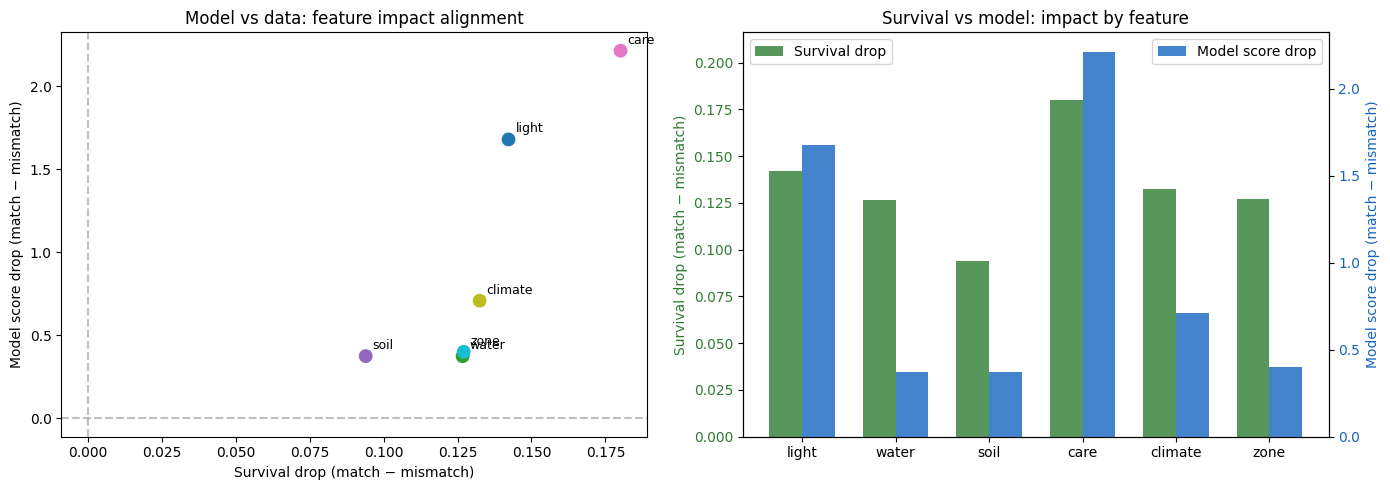

In [66]:
if model_stats:
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")
    # Left: survival drop vs model score drop (scatter)
    surv_drops = [stats[f]["survival_drop"] for f in features]
    model_drops = [model_stats[f]["score_drop"] for f in features]
    axes2[0].scatter(surv_drops, model_drops, c=range(len(features)), cmap="tab10", s=80)
    for i, f in enumerate(features):
        axes2[0].annotate(f, (surv_drops[i], model_drops[i]), xytext=(5, 5), textcoords="offset points", fontsize=9)
    axes2[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
    axes2[0].axvline(0, color="gray", linestyle="--", alpha=0.5)
    axes2[0].set_xlabel("Survival drop (match − mismatch)")
    axes2[0].set_ylabel("Model score drop (match − mismatch)")
    axes2[0].set_title("Model vs data: feature impact alignment")
    # Right: dual bar with dual y-axis (survival 0–1, model unbounded)
    x = range(len(features))
    w = 0.35
    ax_right = axes2[1]
    ax_right.bar([i - w/2 for i in x], surv_drops, w, label="Survival drop", color="#2e7d32", alpha=0.8)
    ax_right.set_xticks(x)
    ax_right.set_xticklabels(features)
    ax_right.set_ylabel("Survival drop (match − mismatch)", color="#2e7d32")
    ax_right.tick_params(axis="y", labelcolor="#2e7d32")
    ax_right.set_ylim(0, max(surv_drops) * 1.2 or 0.25)
    ax2_twin = ax_right.twinx()
    ax2_twin.bar([i + w/2 for i in x], model_drops, w, label="Model score drop", color="#1565c0", alpha=0.8)
    ax2_twin.set_ylabel("Model score drop (match − mismatch)", color="#1565c0")
    ax2_twin.tick_params(axis="y", labelcolor="#1565c0")
    ax_right.set_title("Survival vs model: impact by feature")
    ax_right.legend(loc="upper left")
    ax2_twin.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "model_vs_survival_feature_impact.png", dpi=120, bbox_inches="tight", facecolor="white")
    plt.show()